# Forest Disturbance Detection - Modular Training Pipeline

Clean demonstration of the modularized training workflow.
All code is now organized in the `disturbance_detection` package.

**Sections:**
1. Setup & Configuration
2. Data Loading & Preparation
3. Model Training
4. Evaluation & Visualization

### Setup and Configuration

In [1]:
import pandas as pd
import torch
import os

# Import from our modular package
from disturbance_detection import (
    Config, set_seed,
    prepare_data, print_split_balances, make_or_load_uid_splits,
    SmallUNet1D, FocalLoss,
    safe_to_device,
    final_eval_with_val_threshold,
    count_supervised_positives,
    plot_history, plot_precision_recall_curve, 
    plot_f1_vs_threshold, print_classification_report,
    get_model,
    TemporalCNN,
    MediumUNet1D
)

print("All imports successful!")

All imports successful!


In [2]:
# Create configuration
config = Config()

# Set random seed for reproducibility
set_seed(config.seed)

# Check device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
config.target_mode = "last"

config.focal_alpha = 0.3
config.focal_gamma = 1.9
config.features_mode = "bands_indices"

# Display key configuration
print(f"\nConfiguration:")
print(f"  Features: {config.features_mode} ({config.get_num_features()} features)")
print(f"  Window size: {config.window_size}")
print(f"  Batch size: {config.batch_size}")
print(f"  Epochs: {config.num_epochs}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Focal loss: alpha={config.focal_alpha}, gamma={config.focal_gamma}")

Random seed set to 42
Using device: cuda:0

Configuration:
  Features: bands_indices (12 features)
  Window size: 7
  Batch size: 64
  Epochs: 30
  Learning rate: 0.0003
  Focal loss: alpha=0.3, gamma=1.9


### Dataloading and Preparation

In [3]:
# Load dataset
df = pd.read_csv(config.csv_path, index_col=0, sep=config.csv_separator)
print(f"Loaded {len(df)} samples")

# Create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)

# Filter doubtful samples (optional - from original notebook)
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
#df = df[~((df['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
#df = df[~((df['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

print(f"After filtering: {len(df)} samples")
print(f"\nClass distribution:")
print(df['class_level1'].value_counts())

Loaded 567084 samples
After filtering: 524772 samples

Class distribution:
class_level1
treed          510211
disturbance      8711
non-treed        5850
Name: count, dtype: int64


In [4]:
# Prepare train/val/test splits and dataloaders
train_loader, val_loader, test_loader, n_features, features = prepare_data(df, config)

print(f"\nData preparation complete!")
print(f"Features used: {features}")
print(f"Number of features: {n_features}")
print(f"\nDataLoader sizes:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

[INFO] Loaded existing split file: /home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/Data/new_class2_v5_seed42_uids_w5_v5_results.npz

Data preparation complete!
Features used: ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2', 'NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'DIn']
Number of features: 12

DataLoader sizes:
  Train batches: 4640
  Val batches: 677
  Test batches: 1307


In [5]:
# Check class balance at supervised position
tr_pos, tr_tot, tr_rate = count_supervised_positives(train_loader, config.target_mode, device)
va_pos, va_tot, va_rate = count_supervised_positives(val_loader, config.target_mode, device)
te_pos, te_tot, te_rate = count_supervised_positives(test_loader, config.target_mode, device)

print(f"Class balance at target position ('{config.target_mode}'):")
print(f"  Train: {tr_pos}/{tr_tot} ({100*tr_rate:.3f}% positive)")
print(f"  Val:   {va_pos}/{va_tot} ({100*va_rate:.3f}% positive)")
print(f"  Test:  {te_pos}/{te_tot} ({100*te_rate:.3f}% positive)")

Class balance at target position ('last'):
  Train: 1246/296913 (0.420% positive)
  Val:   185/43275 (0.427% positive)
  Test:  328/83610 (0.392% positive)


### Model Training

In [6]:
# Initialize model
#Select model
config.model_name = "TemporalCNN"
#model = get_model(config)

#or train UNet
#config.model_name = "SmallUNet1D"
#config.model_name = "UNet30"
#config.model_name = "MediumUNet1D"
config.dropout_rate = 0.3
model = get_model(config).to(device)


# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created: {config.model_name}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

Model created: TemporalCNN
  Total parameters: 31,777
  Trainable parameters: 31,777


In [7]:
# Create optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=config.betas,
    eps=config.eps
)


# Create loss function
loss_fn = FocalLoss(
    alpha=config.focal_alpha,
    gamma=config.focal_gamma,
    reduction=config.loss_reduction
)

print("Optimizer: AdamW")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Weight decay: {config.weight_decay}")
print(f"\nLoss: FocalLoss")
print(f"  Alpha: {config.focal_alpha}")
print(f"  Gamma: {config.focal_gamma}")

Optimizer: AdamW
  Learning rate: 0.0003
  Weight decay: 0.0001

Loss: FocalLoss
  Alpha: 0.3
  Gamma: 1.9


In [8]:
'''# ============================================================
# Cell 9: Train Model (Full Supervision)
# ============================================================
#from disturbance_detection.training_full_supervision import train_and_select_best_full_supervision
#from disturbance_detection.training_full_supervision import train_model_full_supervision
from disturbance_detection.training_full_supervision import train_epoch_full_supervision
from disturbance_detection.training_full_supervision import validate_epoch_full_supervision


# Train with FULL supervision on all positions
print(f"\nModel: {config.model_name}")
print(f"\nWindow size: {config.window_size}")
print(f"\nStarting FULL SUPERVISION training for {config.num_epochs} epochs...")
print(f"Training on: ALL valid positions")
print(f"Validation on: Target position only ({config.target_mode})")
print(f"Model selection by: {config.select_by}")
print("-" * 80)


for epoch in range(30): #config.num_epochs):
    print(f"\n--- Epoch {epoch+1} ---")
    train_loss, train_acc, train_f1_all, train_f1_target = train_epoch_full_supervision(
        model, train_loader, optimizer, device, loss_fn, config
    )
    val_loss, val_f1_all, val_f1_target, val_auprc = validate_epoch_full_supervision(
        model, val_loader, device, loss_fn, config
    )

    print(f"Train Loss: {train_loss:.4f} | Train F1(all): {train_f1_all:.4f} | Train F1(target): {train_f1_target:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val F1(all): {val_f1_all:.4f} | Val F1(target): {val_f1_target:.4f} | Val AUPRC: {val_auprc:.4f}")




print("-" * 80)
print(f"\nTraining complete!")
print(f"Best epoch: {best_info['best_epoch']}")
print(f"Best {best_info['select_by']}: {best_info['best_metric']:.4f}")
print(f"Checkpoint saved: {best_info['ckpt_path']}")
'''

'# ============================================================\n# Cell 9: Train Model (Full Supervision)\n# ============================================================\n#from disturbance_detection.training_full_supervision import train_and_select_best_full_supervision\n#from disturbance_detection.training_full_supervision import train_model_full_supervision\nfrom disturbance_detection.training_full_supervision import train_epoch_full_supervision\nfrom disturbance_detection.training_full_supervision import validate_epoch_full_supervision\n\n\n# Train with FULL supervision on all positions\nprint(f"\nModel: {config.model_name}")\nprint(f"\nWindow size: {config.window_size}")\nprint(f"\nStarting FULL SUPERVISION training for {config.num_epochs} epochs...")\nprint(f"Training on: ALL valid positions")\nprint(f"Validation on: Target position only ({config.target_mode})")\nprint(f"Model selection by: {config.select_by}")\nprint("-" * 80)\n\n\nfor epoch in range(30): #config.num_epochs):\n  

In [9]:
'''# Grid Search for Focal Loss Hyperparameters
from disturbance_detection.training_full_supervision import train_full_supervision_with_selection

# define grid search parameters

alpha_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
gamma_values = [1.5, 1.9, 2.0, 2.5]

# Track results
grid_results = []
print("Starting Grid Search for Focal Loss Hyperparameters...")
print("-" * 80)

# Train with best model selection

for alpha in alpha_values:
    for gamma in gamma_values:
        print(f"\nTraining with alpha={alpha}, gamma={gamma}")
        print("-" * 80)
        
        # Update config
        config.focal_alpha = alpha
        config.focal_gamma = gamma

        #Reinitialize model
        model = get_model(config).to(device)

        #Reinitialize optimizer
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
            betas=config.betas,
            eps=config.eps
        )

        #Reinitialize loss function
        loss_fn = FocalLoss(
            alpha=config.focal_alpha,
            gamma=config.focal_gamma,
            reduction=config.loss_reduction
        )

        # Train with best model selection
        history, best_info = train_full_supervision_with_selection(
            model, train_loader, val_loader, optimizer, device, loss_fn, config
        )

        #store results

        results = {
            'alpha': alpha,
            'gamma': gamma,
            'best_epoch': best_info['best_epoch'],
            'best_val_auprc': best_info['best_metric'],
            'best_f1_target': best_info['best_f1_target'],
            'history': history
        }

        grid_results.append(results)

        print(f"\n Results: alpha={alpha}, gamma={gamma}, best epoch={best_info['best_epoch']}, best AUPRC={best_info['best_metric']:.4f}, best F1(target)={best_info['best_f1_target']:.4f}")
        
        
'''

'# Grid Search for Focal Loss Hyperparameters\nfrom disturbance_detection.training_full_supervision import train_full_supervision_with_selection\n\n# define grid search parameters\n\nalpha_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]\ngamma_values = [1.5, 1.9, 2.0, 2.5]\n\n# Track results\ngrid_results = []\nprint("Starting Grid Search for Focal Loss Hyperparameters...")\nprint("-" * 80)\n\n# Train with best model selection\n\nfor alpha in alpha_values:\n    for gamma in gamma_values:\n        print(f"\nTraining with alpha={alpha}, gamma={gamma}")\n        print("-" * 80)\n        \n        # Update config\n        config.focal_alpha = alpha\n        config.focal_gamma = gamma\n\n        #Reinitialize model\n        model = get_model(config).to(device)\n\n        #Reinitialize optimizer\n        optimizer = torch.optim.AdamW(\n            model.parameters(),\n            lr=config.learning_rate,\n            weight_decay=config.weight_decay,\n            betas=config.betas,\n            eps

In [10]:
from disturbance_detection.training_full_supervision import train_full_supervision_with_selection

# Train with best model selection
print(f"\nStarting training for {config.num_epochs} epochs...")
print(f"Model: {config.model_name}")
print(f"Target position: {config.target_mode}")
print(f"Model selection by: {config.select_by}")
print("-" * 80)

history, best_info = train_full_supervision_with_selection(
    model, train_loader, val_loader, optimizer, device, loss_fn, config
)

print("-" * 80)
print(f"\nTraining complete!")
print(f"Best epoch: {best_info['best_epoch']}")
print(f"Best {best_info['select_by']}: {best_info['best_metric']:.4f}")
print(f"Checkpoint saved: {best_info['ckpt_path']}")


Starting training for 30 epochs...
Model: TemporalCNN
Target position: last
Model selection by: auprc
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01 | TrainLoss 0.0016 | TrainF1(all) 0.6067 | TrainF1(target) 0.6244 | ValLoss 0.0006 | ValF1(all) 0.7459 | ValF1* 0.8218 | ValAUPRC 0.8580
Epoch 02 | TrainLoss 0.0006 | TrainF1(all) 0.7037 | TrainF1(target) 0.7278 | ValLoss 0.0006 | ValF1(all) 0.7520 | ValF1* 0.8272 | ValAUPRC 0.8627
Epoch 03 | TrainLoss 0.0006 | TrainF1(all) 0.7184 | TrainF1(target) 0.7449 | ValLoss 0.0006 | ValF1(all) 0.7352 | ValF1* 0.8375 | ValAUPRC 0.8658
Epoch 04 | TrainLoss 0.0006 | TrainF1(all) 0.7291 | TrainF1(target) 0.7437 | ValLoss 0.0006 | ValF1(all) 0.7712 | ValF1* 0.8305 | ValAUPRC 0.8680
Epoch 05 | TrainLoss 0.0006 | TrainF1(all) 0.7296 | TrainF1(target) 0.7514 | ValLoss 0.0006 | ValF1(all) 0.7802 | ValF1* 0.8291 | ValAUPRC 0.8718
Epoch 06 | TrainLoss 0.0006 | TrainF1(all) 0.7389 | TrainF1(target) 0.7532 | ValLoss 0.0006 | ValF1(all) 0.7456 | ValF1* 0.8304 | ValAUPRC 0.8717
Epoch 07 | TrainLoss 0.0006 | TrainF1(all) 0.7399 | TrainF1(target) 0.7575 | ValLoss 0.0006 | ValF1(all) 0.7366 | ValF1* 0.8

### Evaluation and Visualization

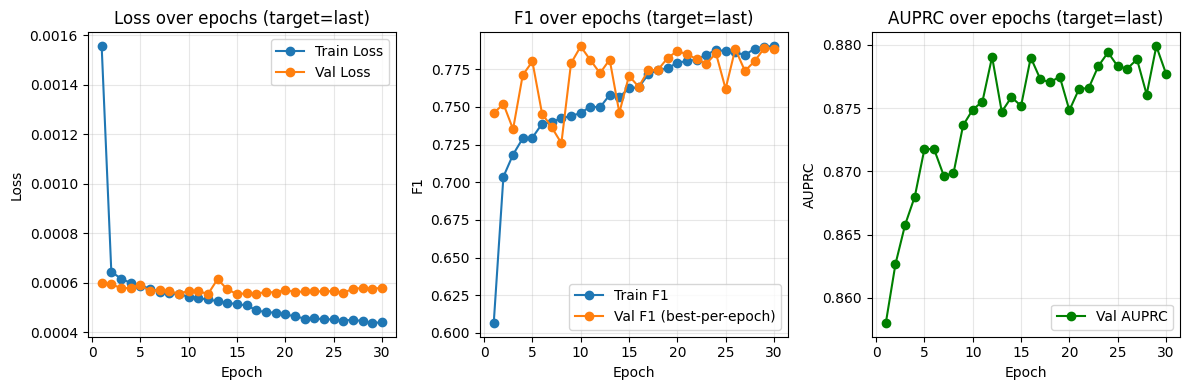

In [11]:
# Import the function with a different name
from disturbance_detection.evaluation import plot_history as plot_training_history

# Create a mapping for the plot function
plot_data = {
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_f1": history["train_f1_all"],  # Use f1_all as the main F1
    "val_f1": history["val_f1_all"],      # Use f1_all as the main F1
    "val_auprc": history["val_auprc"]
}

# Then plot
plot_training_history(plot_data, title_suffix=f" (target={config.target_mode})")

In [12]:
# Load best model and evaluate
print("Evaluating best model on test set...")
print("=" * 80)

best_thr, test_metrics = final_eval_with_val_threshold(
    model, device, config.checkpoint_path,
    val_loader, test_loader, 
    target_mode=config.target_mode
)

print("=" * 80)

Evaluating best model on test set...
Loaded best model from epoch 29.


/home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/disturbance_detection/evaluation.py:194: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental featur

[VAL] thr*=0.446 | F1*=0.844 | AUPRC=0.880
[TEST] thr=0.446 | P=0.891 R=0.726 F1=0.800 Acc=0.999 | AUPRC=0.844
Confusion matrix (TEST) [rows=true 0/1, cols=pred 0/1]:
 [[83253    29]
 [   90   238]]


In [13]:
from disturbance_detection.evaluation import collect_probs

# Collect test predictions
y_true_test, y_prob_test = collect_probs(model, test_loader, device, config.target_mode)

# Print detailed classification report
print_classification_report(
    y_true_test, y_prob_test, best_thr,
    target_names=["Undisturbed (0)", "Disturbed (1)"]
)

Accuracy: 0.999

Classification Report:
                 precision    recall  f1-score   support

Undisturbed (0)      0.999     1.000     0.999     83282
  Disturbed (1)      0.891     0.726     0.800       328

       accuracy                          0.999     83610
      macro avg      0.945     0.863     0.900     83610
   weighted avg      0.998     0.999     0.999     83610



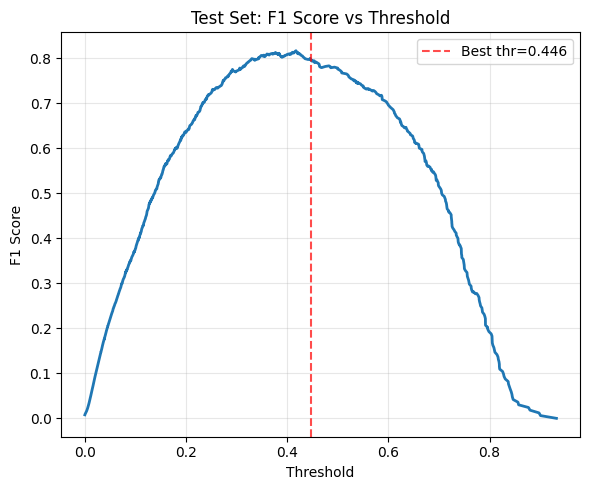

In [14]:
# F1 score as a function of threshold
plot_f1_vs_threshold(y_true_test, y_prob_test, best_thr, 
                     "Test Set: F1 Score vs Threshold")

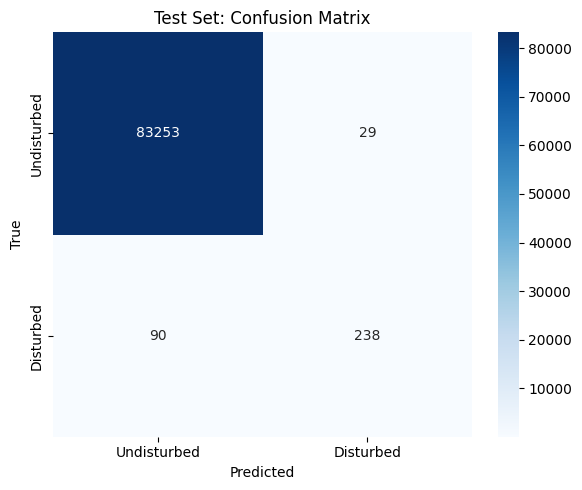

In [15]:
from disturbance_detection.evaluation import plot_confusion_matrix

# Plot confusion matrix
plot_confusion_matrix(test_metrics['cm'], 
                     labels=["Undisturbed", "Disturbed"],
                     title="Test Set: Confusion Matrix")